## 0. Download dataset
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

In [19]:
# https://drive.google.com/file/d/1xwJmYJxEia06sxUdJyGO7JFx4DNK1fbp/view?usp=sharing
!gdown --id 1xwJmYJxEia06sxUdJyGO7JFx4DNK1fbp

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xwJmYJxEia06sxUdJyGO7JFx4DNK1fbp
To: /content/Problem3.csv
100% 37.4k/37.4k [00:00<00:00, 53.9MB/s]


## 1. Import libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

## 2. Load dataset

In [21]:
dataset_path = '/content/Problem3.csv'
data_df = pd.read_csv(dataset_path)
data_df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,4.468204,26.2,94.3,1.808289,8.2,51,6.7,False,0.000000
1,7,4,oct,tue,4.517431,35.4,669.1,2.041220,18.0,33,0.9,False,0.000000
2,7,4,oct,sat,4.517431,43.7,686.9,2.041220,14.6,33,1.3,False,0.000000
3,8,6,mar,fri,4.529368,33.3,77.5,2.302585,8.3,97,4.0,True,0.000000
4,8,6,mar,sun,4.503137,51.3,102.2,2.360854,11.4,99,1.8,False,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,4,3,aug,sun,4.414010,56.7,665.6,1.064711,27.8,32,2.7,False,2.006871
506,2,4,aug,sun,4.414010,56.7,665.6,1.064711,21.9,71,5.8,False,4.012592
507,7,4,aug,sun,4.414010,56.7,665.6,1.064711,21.2,70,6.7,False,2.498152
508,1,4,aug,sat,4.558079,146.0,614.7,2.509599,25.6,42,4.0,False,0.000000


In [22]:
data_df.shape

(510, 13)

In [23]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       510 non-null    int64  
 1   Y       510 non-null    int64  
 2   month   510 non-null    object 
 3   day     510 non-null    object 
 4   FFMC    510 non-null    float64
 5   DMC     510 non-null    float64
 6   DC      510 non-null    float64
 7   ISI     510 non-null    float64
 8   temp    510 non-null    float64
 9   RH      510 non-null    int64  
 10  wind    510 non-null    float64
 11  rain    510 non-null    bool   
 12  area    510 non-null    float64
dtypes: bool(1), float64(7), int64(3), object(2)
memory usage: 48.4+ KB


## 3. Dealing with categorical data


### 3.1. Check categorical data

In [24]:
categorical_cols = data_df.select_dtypes(include=['object', 'bool']).columns.to_list()
categorical_cols

['month', 'day', 'rain']

In [25]:
for col_name in categorical_cols:
    n_categories = data_df[col_name].nunique()
    print(f'Number of categories in {col_name}: {n_categories}')

Number of categories in month: 12
Number of categories in day: 7
Number of categories in rain: 2


### 3.2. Encode Categorical Data

In [26]:
ordinal_encoder = OrdinalEncoder()
encoded_categorical_cols = ordinal_encoder.fit_transform(data_df[categorical_cols])

encoded_categorical_df = pd.DataFrame(
  encoded_categorical_cols ,
  columns = categorical_cols
)

numerical_df = data_df.drop(categorical_cols , axis =1)
encoded_df = pd.concat([numerical_df, encoded_categorical_df ] , axis =1)

In [27]:
encoded_df

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,area,month,day,rain
0,7,5,4.468204,26.2,94.3,1.808289,8.2,51,6.7,0.000000,7.0,0.0,0.0
1,7,4,4.517431,35.4,669.1,2.041220,18.0,33,0.9,0.000000,10.0,5.0,0.0
2,7,4,4.517431,43.7,686.9,2.041220,14.6,33,1.3,0.000000,10.0,2.0,0.0
3,8,6,4.529368,33.3,77.5,2.302585,8.3,97,4.0,0.000000,7.0,0.0,1.0
4,8,6,4.503137,51.3,102.2,2.360854,11.4,99,1.8,0.000000,7.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,4,3,4.414010,56.7,665.6,1.064711,27.8,32,2.7,2.006871,1.0,3.0,0.0
506,2,4,4.414010,56.7,665.6,1.064711,21.9,71,5.8,4.012592,1.0,3.0,0.0
507,7,4,4.414010,56.7,665.6,1.064711,21.2,70,6.7,2.498152,1.0,3.0,0.0
508,1,4,4.558079,146.0,614.7,2.509599,25.6,42,4.0,0.000000,1.0,2.0,0.0


## 4. Train test split

In [28]:
X = encoded_df.drop(columns=['area'])
y = encoded_df['area']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

In [30]:
print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of val samples: {X_test.shape[0]}')

Number of training samples: 357
Number of val samples: 153


## 5. Training

In [31]:
xg_reg = xgb.XGBRegressor(seed=7, learning_rate=0.01, n_estimators=102, max_depth=3)

In [32]:
xg_reg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=102, n_jobs=None, num_parallel_tree=None,
             predictor=None, random_state=None, ...)

## 6. Evaluation

In [33]:
preds = xg_reg.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)

print('Evaluation results on test set:')
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')

Evaluation results on test set:
Mean Absolute Error: 1.0922937068201708
Mean Squared Error: 1.8814015748734487


In [35]:
preds # 0.85726804

array([0.85726804, 0.83457035, 0.6043245 , 1.841135  , 1.0618896 ,
       0.96908915, 1.0917528 , 0.9443598 , 0.8348888 , 0.89880306,
       0.94315255, 0.9693438 , 0.85481805, 0.69285345, 0.82738155,
       1.0886577 , 0.6923953 , 0.8350719 , 0.76176345, 0.935043  ,
       0.9842896 , 1.1046971 , 0.73317623, 1.0174714 , 0.94015205,
       0.9148287 , 0.75870335, 0.7321911 , 0.9286919 , 1.0102396 ,
       0.94005454, 1.0865042 , 0.95106673, 1.0871437 , 1.0897756 ,
       0.7451683 , 0.98183453, 0.9443598 , 0.8478173 , 1.0645987 ,
       0.91725016, 0.9928744 , 0.6352235 , 1.4836442 , 0.82761997,
       0.80327463, 0.90291697, 0.9210329 , 0.8123437 , 0.95106673,
       0.72909147, 0.75889456, 1.1067324 , 0.98879766, 1.1389079 ,
       0.8681198 , 0.6264487 , 0.99517035, 0.8856383 , 1.0917528 ,
       0.81698346, 0.8828686 , 0.69221777, 0.92695445, 1.0167683 ,
       0.536421  , 1.1088318 , 0.8151888 , 0.7917446 , 0.80859214,
       0.65062356, 0.94315255, 1.0244209 , 1.0118768 , 0.85488

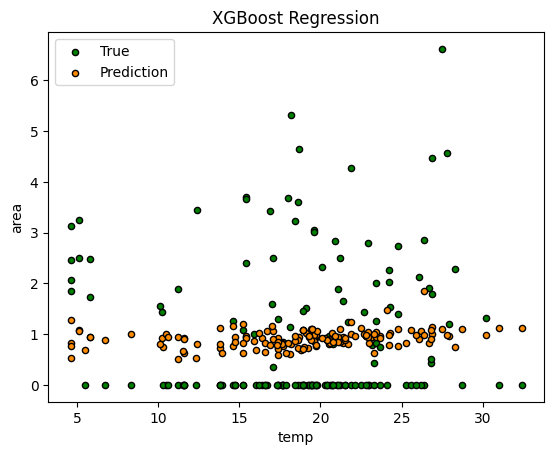

In [36]:
plt.figure()
plt.scatter(X_test['temp'], y_test, s=20, edgecolor="black", c="green", label="True")
plt.scatter(X_test['temp'], preds, s=20, edgecolor="black", c="darkorange", label="Prediction")
plt.xlabel("temp")
plt.ylabel("area")
plt.title("XGBoost Regression")
plt.legend()
plt.show()